# Pleiades Gaia colour–magnitude sequence audit

**Scientific question:** How narrow is the selected Pleiades sequence, and how sensitive is it to astrometric quality cuts?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
raw=pd.read_csv(DATA/'pleiades_gaia_dr3_query.csv'); base=raw.dropna(subset=['parallax','parallax_error','phot_g_mean_mag','bp_rp','ruwe']).copy(); base['snr']=base.parallax/base.parallax_error; base['abs_g']=base.phot_g_mean_mag-5*np.log10(1000/base.parallax)+5; sample=base[(base.snr>10)&(base.ruwe<1.4)&base.bp_rp.between(-.2,4.2)].copy(); print(len(sample),'quality-selected Gaia rows')

690 quality-selected Gaia rows


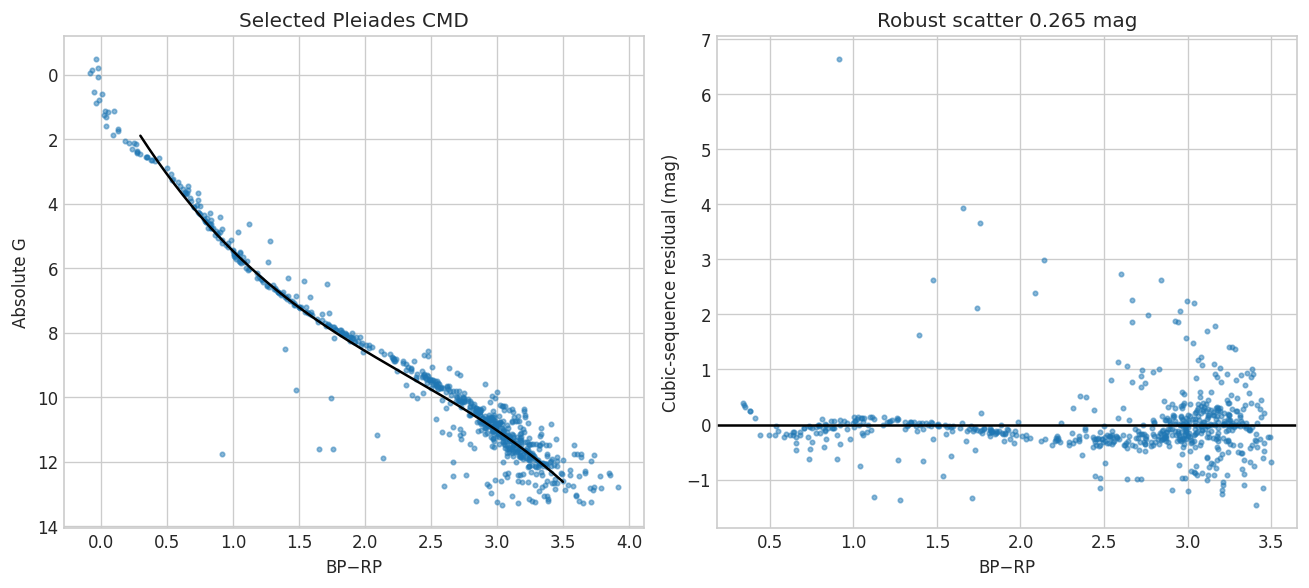

In [3]:
x=sample.bp_rp.to_numpy(); y=sample.abs_g.to_numpy(); use=(x>.3)&(x<3.5); coef=np.polyfit(x[use],y[use],3); resid=y-np.polyval(coef,x); scatter=1.4826*np.median(np.abs(resid[use]-np.median(resid[use]))); fig,ax=plt.subplots(1,2,figsize=(11,5)); ax[0].scatter(x,y,s=7,alpha=.5); grid=np.linspace(.3,3.5,200); ax[0].plot(grid,np.polyval(coef,grid),'k'); ax[0].invert_yaxis(); ax[0].set(xlabel='BP−RP',ylabel='Absolute G',title='Selected Pleiades CMD'); ax[1].scatter(x[use],resid[use],s=7,alpha=.5); ax[1].axhline(0,color='k'); ax[1].set(xlabel='BP−RP',ylabel='Cubic-sequence residual (mag)',title=f'Robust scatter {scatter:.3f} mag'); fig.tight_layout(); fig.savefig('pleiades_cmd_sequence_audit.png',dpi=180); plt.show()

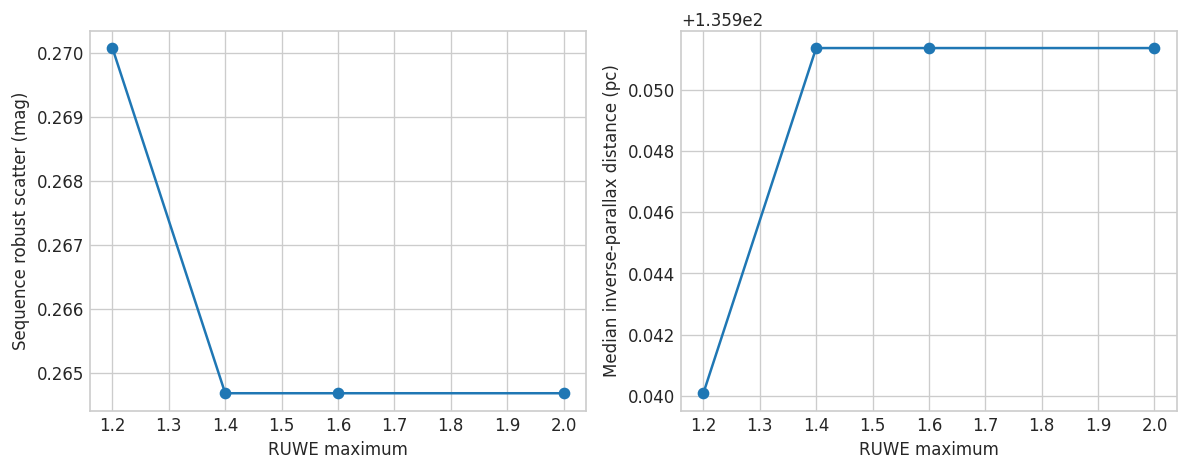

In [4]:
rows=[]
for cut in [1.2,1.4,1.6,2.0]:
 s=base[(base.snr>10)&(base.ruwe<cut)&base.bp_rp.between(.3,3.5)].copy(); c=np.polyfit(s.bp_rp,s.abs_g,3); r=s.abs_g-np.polyval(c,s.bp_rp); rows.append((cut,len(s),1.4826*np.median(np.abs(r-np.median(r))),np.median(1000/s.parallax)))
stress=pd.DataFrame(rows,columns=['ruwe_max','n','sequence_mad_mag','median_distance_pc']); stress.to_csv('pleiades_quality_stress.csv',index=False); fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].plot(stress.ruwe_max,stress.sequence_mad_mag,'o-'); ax[0].set(xlabel='RUWE maximum',ylabel='Sequence robust scatter (mag)'); ax[1].plot(stress.ruwe_max,stress.median_distance_pc,'o-'); ax[1].set(xlabel='RUWE maximum',ylabel='Median inverse-parallax distance (pc)'); fig.tight_layout(); fig.savefig('pleiades_quality_stress.png',dpi=180); plt.show()

In [5]:
dist_boot=bootstrap(1000/sample.parallax); lo,hi=np.percentile(dist_boot,[16,84]); sample_size=len(sample); results=[f'{sample_size} quality-selected sources',f'cubic-sequence robust scatter {scatter:.3f} mag',f'median inverse-parallax distance {np.median(1000/sample.parallax):.2f} pc; bootstrap 68% {lo:.2f}–{hi:.2f} pc']; validation='Sequence width and distance are repeated across four RUWE thresholds.'; quality_checks=[{'name':'Parallax S/N > 10','status':'pass'},{'name':'RUWE threshold sweep','status':'pass'},{'name':'Bootstrap distance','status':'pass'}]; tags=['Gaia','Pleiades','CMD','quality cuts']

In [6]:
result={'id':'2026-07-30-hr-diagram-pleiades','title':'Pleiades Gaia colour–magnitude sequence audit','archive':'Gaia DR3','date':'2026-07-30','question':'How narrow is the selected Pleiades sequence, and how sensitive is it to astrometric quality cuts?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'gaia/2026-07-30-hr-diagram-pleiades/notebook.ipynb','hero':'gaia/2026-07-30-hr-diagram-pleiades/pleiades_cmd_sequence_audit.png','figures':['gaia/2026-07-30-hr-diagram-pleiades/pleiades_cmd_sequence_audit.png', 'gaia/2026-07-30-hr-diagram-pleiades/pleiades_quality_stress.png'],'research_level':'Validated','claim_type':'Cluster sequence measurement','provenance':['Gaia DR3 saved query', 'source-level parallax, photometry, proper motion, and RUWE retained'],'artifacts':['data/audit_batches4_7/pleiades_gaia_dr3_query.csv', 'gaia/2026-07-30-hr-diagram-pleiades/pleiades_quality_stress.csv'],'quality_checks':quality_checks,'limitations':['inverse parallax is used only at high S/N', 'cubic sequence is empirical, not an isochrone', 'unresolved binaries and extinction broaden the sequence'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

690 quality-selected sources
cubic-sequence robust scatter 0.265 mag
median inverse-parallax distance 136.04 pc; bootstrap 68% 135.92–136.19 pc


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                name status
   Parallax S/N > 10   pass
RUWE threshold sweep   pass
  Bootstrap distance   pass


## Interpretation and references

Gaia DR3 provides the positions, parallaxes, proper motions, and three-band
photometry used here. Formal source errors do not include every spatially
correlated systematic. Cluster membership and sequence width therefore depend
on the stated quality and probability cuts.

- Gaia DR3 summary: https://doi.org/10.1051/0004-6361/202243940
- Gaia astrometric solution: https://doi.org/10.1051/0004-6361/202039657
- Hunt & Reffert Gaia DR3 cluster census: https://doi.org/10.1051/0004-6361/202346285